In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Question  1

In [2]:
def data_to_csv() :
    
    player = pd.read_clipboard();  # read form clipboard

    player.columns = player.columns.str.strip()  # remove whitespace
    
    player = player.drop(columns = [c for c in player.columns if "Unnamed" in c]) #remove column with no name

    player = player.drop('Start DateAscending',axis = 1) # remove date column as i just wnat to do numerical analysis
    player["Runs"] = (   # Replace 'Did Not Bat' with NaN
                 player["Runs"].str.replace("*", "", regex=False).str.replace("DNB", "NA")
    ) 
    
    player["Runs"] = pd.to_numeric(player["Runs"], errors="coerce")
    player.replace(['–', '-'], np.nan, inplace=True) # In ESPN for some matches there is no data for mins and it just '-' so i also remove this type of row
    player = player.dropna()  # remove row if any column value if NaN
    player = player.reset_index(drop=True)  # reset index from 0 to last number

    player.loc[:, "Opposition"] = player["Opposition"].str.replace("v ", "", regex=False)  # remove v in oposition
    player.loc[:, "Ground"] = player["Ground"].str.strip()   # remove whitespace in ground
    player.loc[:, "Opposition"] = player["Opposition"].str.strip()  # rmeove whitespace in opposition
    player.loc[:, "NotOut"] = player["Dismissal"].eq("not out").astype(int)

    columns_numeric = ["BF", "4s", "6s", "Pos", "Inns", "SR", "Mins"]
    for c in columns_numeric:
        player[c] = pd.to_numeric(player[c], errors="coerce")

    file_name = "Kohli_ODI.csv"
    player.to_csv(file_name, index=False)

### run above function for three time with different file name to get three csv file

# Question 2 and 3

In [3]:
vk = pd.read_csv('Kohli_ODI.csv')   # VIRAT KOHLI
ks = pd.read_csv('Sangakkara_ODI.csv')   # KUMAR SANGAKKARA
rp = pd.read_csv('Ponting_ODI.csv')    # RICKY PONTING

In [4]:
vk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Runs        261 non-null    float64
 1   Mins        261 non-null    int64  
 2   BF          261 non-null    int64  
 3   4s          261 non-null    int64  
 4   6s          261 non-null    int64  
 5   SR          261 non-null    float64
 6   Pos         261 non-null    int64  
 7   Dismissal   261 non-null    object 
 8   Inns        261 non-null    int64  
 9   Opposition  261 non-null    object 
 10  Ground      261 non-null    object 
 11  NotOut      261 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 24.6+ KB


In [5]:
ks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Runs        357 non-null    float64
 1   Mins        357 non-null    int64  
 2   BF          357 non-null    int64  
 3   4s          357 non-null    int64  
 4   6s          357 non-null    int64  
 5   SR          357 non-null    float64
 6   Pos         357 non-null    int64  
 7   Dismissal   357 non-null    object 
 8   Inns        357 non-null    int64  
 9   Opposition  357 non-null    object 
 10  Ground      357 non-null    object 
 11  NotOut      357 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 33.6+ KB


In [6]:
rp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Runs        345 non-null    float64
 1   Mins        345 non-null    int64  
 2   BF          345 non-null    int64  
 3   4s          345 non-null    int64  
 4   6s          345 non-null    int64  
 5   SR          345 non-null    float64
 6   Pos         345 non-null    int64  
 7   Dismissal   345 non-null    object 
 8   Inns        345 non-null    int64  
 9   Opposition  345 non-null    object 
 10  Ground      345 non-null    object 
 11  NotOut      345 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 32.5+ KB


In [7]:
vk.columns

Index(['Runs', 'Mins', 'BF', '4s', '6s', 'SR', 'Pos', 'Dismissal', 'Inns',
       'Opposition', 'Ground', 'NotOut'],
      dtype='object')

# Question 4

C:\Users\heet5\AppData\Local\Temp\ipykernel_22084\2802572262.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Kohli","Sangakkara","Ponting"])


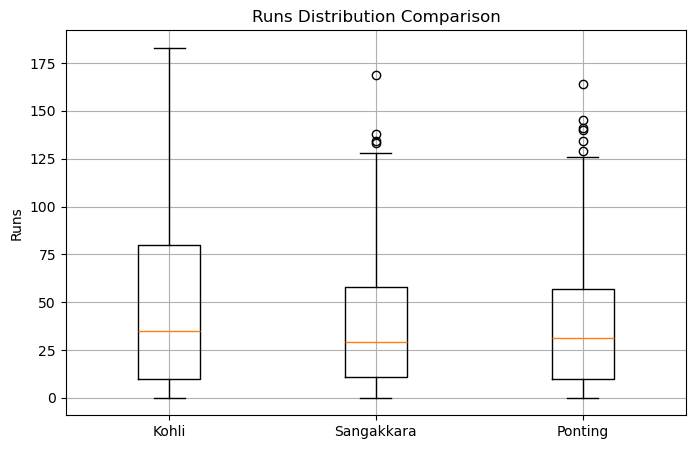

In [8]:
plt.figure(figsize=(8,5))

data = [
    vk["Runs"],
    ks["Runs"],
    rp["Runs"]
]

plt.boxplot(data, labels=["Kohli","Sangakkara","Ponting"])
plt.title("Runs Distribution Comparison")
plt.ylabel("Runs")
plt.grid(True)

plt.show()

In [9]:
# add new column of player anme and then combine three of them in one df
vk["Player"] = "Kohli"
ks["Player"] = "Sangakkara"
rp["Player"] = "Ponting"

In [10]:
# Combine data
df = pd.concat([vk, ks, rp], ignore_index=True)

In [11]:
df[::100] # now i cna do analysis of df using player column

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,NotOut,Player
0,12.0,33,22,1,0,54.54,2,lbw,1,Sri Lanka,Dambulla,0,Kohli
100,115.0,133,108,13,1,106.48,3,caught,2,Zimbabwe,Harare,0,Kohli
200,120.0,179,125,14,1,96.00,3,caught,1,West Indies,Port of Spain,0,Kohli
300,41.0,60,57,5,0,71.92,3,caught,1,South Africa,Tangier,0,Sangakkara
400,22.0,59,27,3,0,81.48,3,caught,1,Pakistan,Colombo (SSC),0,Sangakkara
500,45.0,62,52,4,0,86.53,4,caught,1,Australia,Sydney,0,Sangakkara
600,63.0,110,62,7,0,101.61,3,caught,1,England,Hambantota,0,Sangakkara
700,24.0,32,27,3,0,88.88,3,caught,2,Pakistan,Lord's,0,Ponting
800,69.0,122,93,4,1,74.19,3,caught,2,Sri Lanka,Dambulla,0,Ponting
900,15.0,37,27,2,0,55.55,3,caught,2,New Zealand,Adelaide,0,Ponting


In [12]:
summary = df.groupby("Player").agg(
    Total_Runs=("Runs","sum"),
    Matches=("Runs","count"),
    Avg_Runs=("Runs","mean"),
    Total_4s=("4s","sum"),
    Total_6s=("6s","sum"),
    Total_NotOut=("NotOut","sum"),
    Avg_SR=("SR","mean")
)

summary["Total_Boundaries"] = summary["Total_4s"] + summary["Total_6s"]
summary["50s"] = df[(df["Runs"]>=50) & (df["Runs"]<100)].groupby("Player")["Runs"].count()
summary["100s"] = df[df["Runs"]>=100].groupby("Player")["Runs"].count()
summary['Duck'] = df.groupby('Player')['Runs'].apply(lambda x: (x == 0).sum())
summary

,Total_Runs,Matches,Avg_Runs,Total_4s,Total_6s,Total_NotOut,Avg_SR,Total_Boundaries,50s,100s,Duck
Player,,,,,,,,,,,
Kohli,12634.0,261,48.406130,1168,145,42,79.185939,1313,66,46,16
Ponting,13243.0,345,38.385507,1190,159,34,70.128667,1349,79,30,18
Sangakkara,13788.0,357,38.621849,1346,88,38,73.094398,1434,90,25,11


### From the above analysis, we can see that even though Kohli has played 80–90 fewer matches compared to the other two players, he still has more centuries, a higher average, and higher third quartile and IQR  (based on the box plot)

### and nealy same total boundries, 50s , total runs

# Question 5

### so i pickes Kohli through analysis and he is my favourite player also

#### A).Does the position that they bat in affect their total score or strike rate?

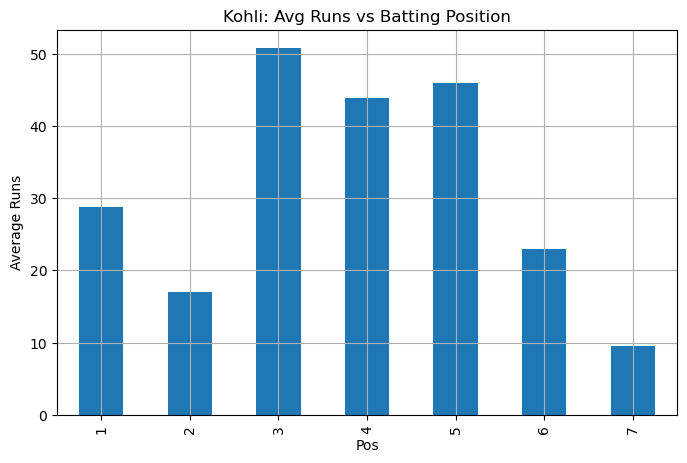

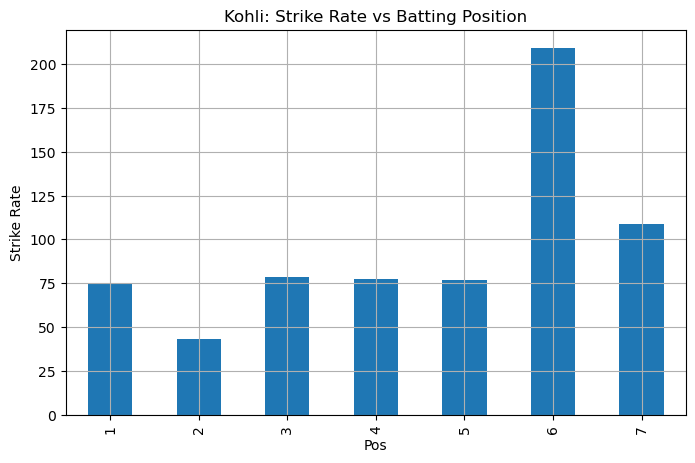

In [13]:
# Average Runs vs Position
vk.groupby("Pos")["Runs"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Kohli: Avg Runs vs Batting Position")
plt.ylabel("Average Runs")
plt.grid()
plt.show()

# Average SR vs Position
vk.groupby("Pos")["SR"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Kohli: Strike Rate vs Batting Position")
plt.ylabel("Strike Rate")
plt.grid()
plt.show()

In [14]:
vk['Pos'].value_counts()

Pos
3    214
4     33
1      4
7      4
2      3
5      2
6      1
Name: count, dtype: int64

#### kohli avg. run is highest in 3 down, and slightly less in 4th down all other batting position is outlier

#### B) Does the innings they bat in affect their average score?

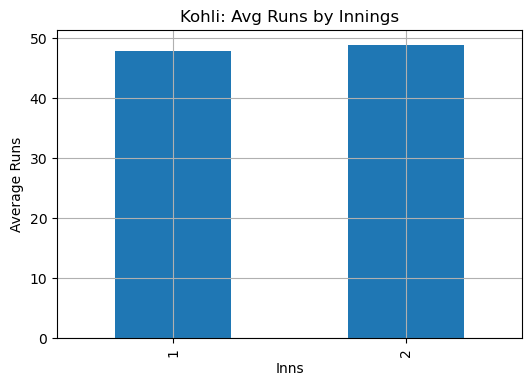

In [15]:
vk.groupby("Inns")["Runs"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Kohli: Avg Runs by Innings")
plt.ylabel("Average Runs")
plt.grid()
plt.show()

In [16]:
vk['Inns'].value_counts()

Inns
2    140
1    121
Name: count, dtype: int64

#### Innings kohli bat has almost no affect on their avg score, it almost same

#### C)Is there a pattern in how they get out with respect to their best and worst performing country? That is, does their manner of dismissal change w.r.t. the team they have the highest mean score or strike rate vs. the team that they do the worst against? 

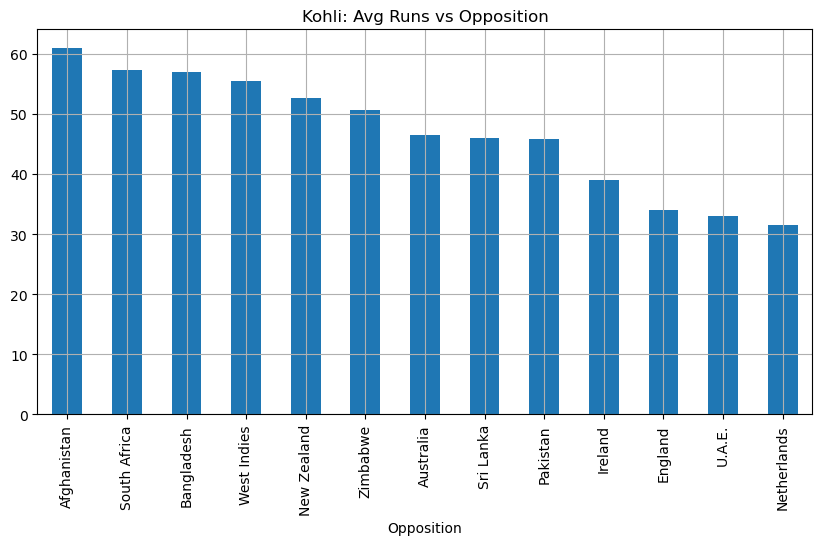

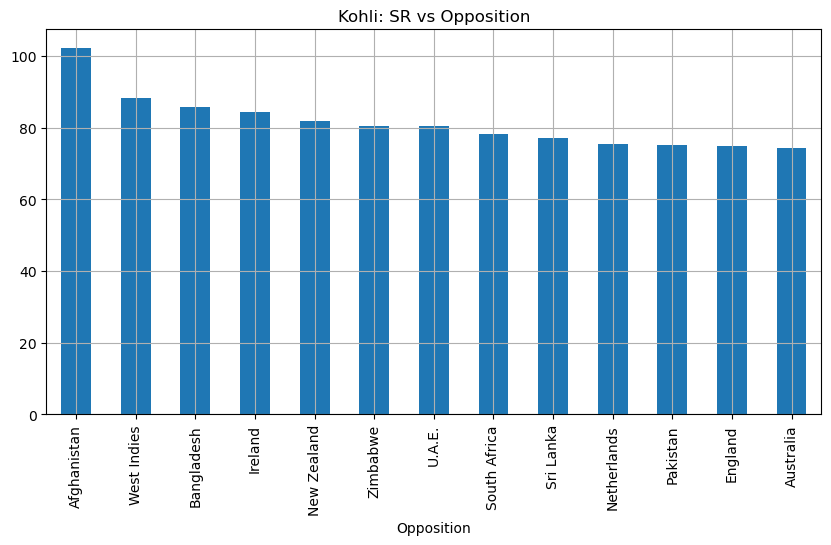

In [17]:
# mean runs vs opposition
vk_runs_opp = vk.groupby("Opposition")["Runs"].mean()

# mean SR vs opposition
vk_sr_opp = vk.groupby("Opposition")["SR"].mean()

# plot runs
vk_runs_opp.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Kohli: Avg Runs vs Opposition")
plt.grid()
plt.show()

# plot SR
vk_sr_opp.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Kohli: SR vs Opposition")
plt.grid()
plt.show()

#### best avg runs and SR is against AFGHANISTAN

#### worst avg is against NETHERLANDS and worst SR is against AUSTRALIA

In [18]:
vk['Opposition'].value_counts()

Opposition
Sri Lanka       46
Australia       39
New Zealand     36
England         35
West Indies     30
South Africa    30
Pakistan        17
Bangladesh      16
Zimbabwe         5
Ireland          2
Netherlands      2
Afghanistan      2
U.A.E.           1
Name: count, dtype: int64

In [19]:
#### as from above Kohli only played 2 matches against Afghanistan so I took WEST INDIES as best opposition

In [20]:
# Best team dismissal
best_dismissal = vk[vk["Opposition"] == 'West Indies']["Dismissal"].value_counts()

# Worst SR team dismissal
worst_dismissal = vk[vk["Opposition"] == 'Australia']["Dismissal"].value_counts()

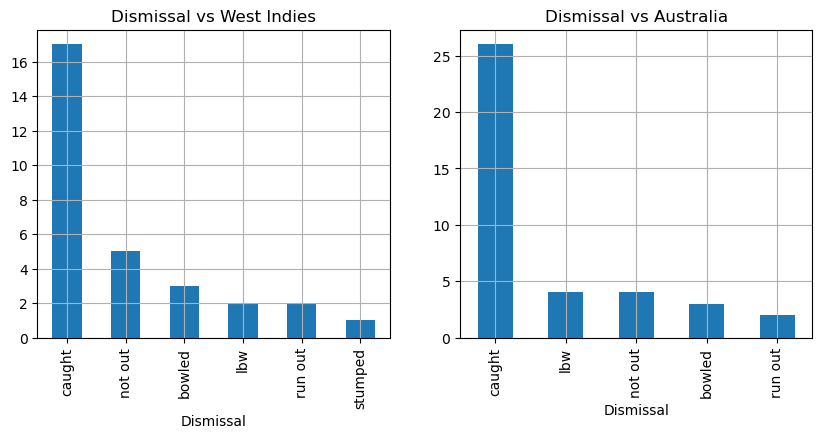

In [22]:
# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
best_dismissal.plot(kind="bar")
plt.title("Dismissal vs West Indies")
plt.grid()

plt.subplot(1,2,2)
worst_dismissal.plot(kind="bar")
plt.title("Dismissal vs Australia")
plt.grid()

plt.show()

#### so both worst and best opposition kohli gots out mosta of the time by caught